# Chaos and the Butterfly Effect

Lorenz system with $\sigma = 10$, $\rho = 28$, $\beta = 8/3$, integrated by fixed-step RK4
(`lorenz.py`). Measurement tools are in `chaos.py`; fast unit checks are in `test_chaos.py`.

Each section ends with a printed **CHECK** line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

from lorenz import integrate
from chaos import on_attractor, separation, fit_lambda, z_maxima, lyapunov_spectrum

DT = 0.01

## 1. The attractor

One trajectory, started on the attractor and run for $t = 100$.

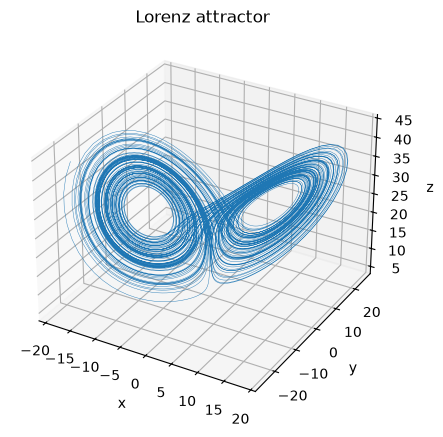

max|x| = 18.6, max|y| = 25.4, z in [3.8, 45.0], <z> = 23.47
CHECK 1 (bounded, <z> = 23.5 +- 1): PASS


In [2]:
traj = integrate(on_attractor(1, seed=0)[0], DT, round(100 / DT))
x, y, z = traj.T

ax = plt.figure(figsize=(6, 5)).add_subplot(projection="3d")
ax.plot(x, y, z, lw=0.3)
ax.set(xlabel="x", ylabel="y", zlabel="z", title="Lorenz attractor")
plt.show()

bounded = np.abs(x).max() < 30 and np.abs(y).max() < 30 and 0 < z.min() and z.max() < 50
print(f"max|x| = {np.abs(x).max():.1f}, max|y| = {np.abs(y).max():.1f}, z in [{z.min():.1f}, {z.max():.1f}], <z> = {z.mean():.2f}")
print("CHECK 1 (bounded, <z> = 23.5 +- 1):", "PASS" if bounded and abs(z.mean() - 23.5) < 1 else "FAIL")

## 2. Two trajectories a distance $\delta$ apart

Two hundred points on the attractor, each paired with a copy displaced by $\delta = 10^{-9}$ in a
random direction. Thin lines are 20 of the individual pairs; the thick line is the geometric mean
$\exp\langle \ln d \rangle$. Averaging $\ln d$ (not $d$) is what matches the definition of
$\lambda$ as an average exponential rate.

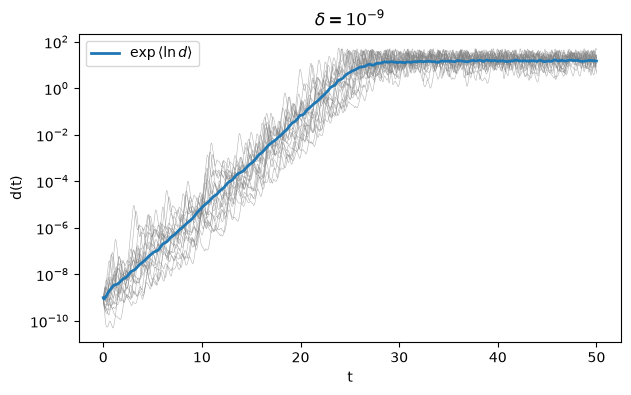

early slope = 0.916, plateau slope = 0.003, plateau d = 15.2
CHECK 2 (exponential growth, then flat at attractor size): PASS


In [3]:
s0 = on_attractor(200, seed=1)   # 20 pairs gives a seed-dependent lambda (+-7%); 200 settles it to ~2%
T_RUN = 50

def mean_log_sep(delta):
    t, d = separation(s0, delta, DT, round(T_RUN / DT))
    return t, np.log(d), np.log(d).mean(axis=1)

t, log_d, m = mean_log_sep(1e-9)

plt.figure(figsize=(7, 4))
plt.semilogy(t, np.exp(log_d[:, :20]), lw=0.4, color="gray", alpha=0.6)
plt.semilogy(t, np.exp(m), lw=2, color="C0", label=r"$\exp\langle\ln d\rangle$")
plt.xlabel("t"); plt.ylabel("d(t)"); plt.legend(); plt.title(r"$\delta = 10^{-9}$")
plt.show()

sat = m[t > T_RUN - 10].mean()                       # plateau level of <ln d>
early = fit_lambda(t, m, 5, 15)                      # growth rate in the middle of the run
late = fit_lambda(t, m, T_RUN - 10, T_RUN)           # drift on the plateau
print(f"early slope = {early:.3f}, plateau slope = {late:.3f}, plateau d = {np.exp(sat):.1f}")
print("CHECK 2 (exponential growth, then flat at attractor size):",
      "PASS" if early > 0.7 and abs(late) < 0.05 and 1 < np.exp(sat) < 40 else "FAIL")

## 3. Fitting $\lambda$

Window rule. The fit starts at $t = 1$: before that the random initial displacement has not yet
rotated into the most unstable direction. The fit stops where $\langle \ln d\rangle$ comes within
3 e-folds of the plateau: past that, nonlinearity folds the separation back and the slope falls.
Shrinking $\delta$ lengthens the linear stretch by $\ln(\delta_1/\delta_2)/\lambda$, so the
window end moves with $\delta$.

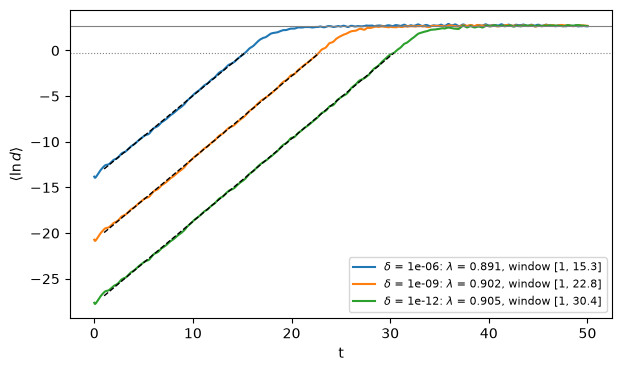

delta = 1e-06: lambda = 0.8914  (-1.6% vs 0.9056)
delta = 1e-09: lambda = 0.9017  (-0.4% vs 0.9056)
delta = 1e-12: lambda = 0.9053  (-0.0% vs 0.9056)
CHECK 3 (within 5% of 0.906, three deltas agree to 5%): PASS


In [4]:
LAMBDA_LIT = 0.9056

def window_end(t, m, sat):
    return t[np.argmax(m > sat - 3)]

plt.figure(figsize=(7, 4))
lams = {}
for delta in (1e-6, 1e-9, 1e-12):
    t, _, m = mean_log_sep(delta)
    t_max = window_end(t, m, sat)
    lams[delta] = lam = fit_lambda(t, m, 1, t_max)
    w = (t >= 1) & (t <= t_max)
    plt.plot(t, m, label=rf"$\delta$ = {delta:g}: $\lambda$ = {lam:.3f}, window [1, {t_max:.1f}]")
    plt.plot(t[w], np.polyval(np.polyfit(t[w], m[w], 1), t[w]), "k--", lw=1)
plt.axhline(sat, color="gray", lw=0.8); plt.axhline(sat - 3, color="gray", lw=0.8, ls=":")
plt.xlabel("t"); plt.ylabel(r"$\langle \ln d \rangle$"); plt.legend(fontsize=8)
plt.show()

vals = np.array(list(lams.values()))
for delta, lam in lams.items():
    print(f"delta = {delta:g}: lambda = {lam:.4f}  ({100 * (lam / LAMBDA_LIT - 1):+.1f}% vs {LAMBDA_LIT})")
ok = np.all(np.abs(vals / LAMBDA_LIT - 1) < 0.05) and vals.max() / vals.min() - 1 < 0.05
print("CHECK 3 (within 5% of 0.906, three deltas agree to 5%):", "PASS" if ok else "FAIL")

## 4. What *is* reproducible

Four long runs ($t = 1000$):
**ref**; **perturbed** (ref $+\,10^{-9}$); **dt/2** (same start, $dt = 0.005$);
**other start** (a different point on the attractor).

The individual trajectories disagree after $t \approx \ln(\text{size}/\delta)/\lambda \approx 25$.
The statistics of the attractor — the distribution of $z$, its mean, and the Lorenz map
$z_{\max,n} \mapsto z_{\max,n+1}$ — should not.

In the figure below, the left panel is the contrast (the trajectory itself is not reproducible);
the middle and right panels are the claim (the statistics are).

Quantitative test: a two-sample KS test on $z$ thinned to one sample per time unit (so samples
are roughly independent), and $\langle z\rangle$ compared using standard errors from blocks of
20 time units.

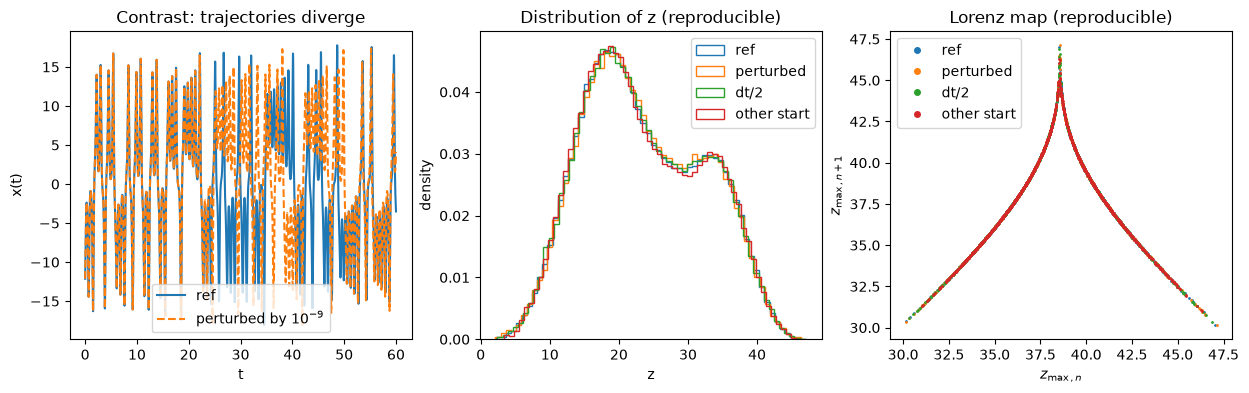

ref and perturbed first differ by |dx| > 1 at t = 21.9
perturbed   : KS p = 0.54, <z> = 23.57 +- 0.05 vs 23.55 +- 0.04 (0.4 sigma)
dt/2        : KS p = 0.20, <z> = 23.55 +- 0.03 vs 23.55 +- 0.04 (0.1 sigma)
other start : KS p = 0.50, <z> = 23.52 +- 0.03 vs 23.55 +- 0.04 (0.5 sigma)
CHECK 4 (z statistics agree: KS p > 0.01 and <z> within 3 sigma): PASS


In [5]:
T_LONG = 1000
ref0 = on_attractor(1, seed=2)[0]
other0 = on_attractor(1, seed=3)[0]

batch = integrate(np.stack([ref0, ref0 + 1e-9 / np.sqrt(3), other0]), DT, round(T_LONG / DT))
half = integrate(ref0, DT / 2, round(T_LONG / (DT / 2)))[::2]   # resample onto the DT grid
runs = {"ref": batch[:, 0], "perturbed": batch[:, 1], "dt/2": half, "other start": batch[:, 2]}
t_long = DT * np.arange(len(half))

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
k = t_long <= 60
axs[0].plot(t_long[k], runs["ref"][k, 0], label="ref")
axs[0].plot(t_long[k], runs["perturbed"][k, 0], "--", label=r"perturbed by $10^{-9}$")
axs[0].set(xlabel="t", ylabel="x(t)", title="Contrast: trajectories diverge"); axs[0].legend()
for name, r in runs.items():
    axs[1].hist(r[:, 2], bins=60, density=True, histtype="step", label=name)
    zm = z_maxima(r[:, 2])
    axs[2].plot(zm[:-1], zm[1:], ".", ms=2, label=name)
axs[1].set(xlabel="z", ylabel="density", title="Distribution of z (reproducible)"); axs[1].legend()
axs[2].set(xlabel=r"$z_{\max,n}$", ylabel=r"$z_{\max,n+1}$", title="Lorenz map (reproducible)"); axs[2].legend(markerscale=4)
plt.show()

def mean_and_se(z, block=round(20 / DT)):
    b = z[: len(z) // block * block].reshape(-1, block).mean(axis=1)
    return z.mean(), b.std(ddof=1) / np.sqrt(len(b))

dx = np.abs(runs["ref"][:, 0] - runs["perturbed"][:, 0])
print(f"ref and perturbed first differ by |dx| > 1 at t = {t_long[np.argmax(dx > 1)]:.1f}")

thin = round(1 / DT)
z_ref = runs["ref"][:, 2]
mu_ref, se_ref = mean_and_se(z_ref)
ok = True
for name in ("perturbed", "dt/2", "other start"):
    z_r = runs[name][:, 2]
    p = ks_2samp(z_ref[::thin], z_r[::thin]).pvalue
    mu, se = mean_and_se(z_r)
    nsig = abs(mu - mu_ref) / np.hypot(se, se_ref)
    ok &= p > 0.01 and nsig < 3
    print(f"{name:12s}: KS p = {p:.2f}, <z> = {mu:.2f} +- {se:.2f} vs {mu_ref:.2f} +- {se_ref:.2f} ({nsig:.1f} sigma)")
print("CHECK 4 (z statistics agree: KS p > 0.01 and <z> within 3 sigma):", "PASS" if ok else "FAIL")

# Push Harder

## 5. How far ahead can you predict?

Define the predictability time $T_{\rm pred}$ as the first time a pair's separation exceeds
$\Delta = 1$ (a few percent of the attractor size). If $d(t) \approx \delta\, e^{\lambda t}$, then

$$T_{\rm pred} \approx \frac{1}{\lambda}\ln\frac{\Delta}{\delta},$$

so every factor of 10 improvement in $\delta$ buys a **fixed** extra $\ln 10/\lambda \approx 2.5$
time units, not a proportional one. The sweep runs $\delta = 10^{-1}\ldots10^{-16}$ with the same
200 starting points as section 2. The fit uses $10^{-2}\ldots10^{-13}$. $10^{-1}$ is excluded
because it is already nonlinear at $t=0$, and $\delta \le 10^{-14}$ is excluded because it reaches
the float64 floor: a coordinate of size $\sim 20$ is resolved only to $20 \cdot 2.2\times10^{-16}
\approx 4\times10^{-15}$, so smaller displacements are rounded or vanish entirely.
Past that floor, $T_{\rm pred}$ stops growing (about 34): a better $\delta$ buys nothing,
because the machine cannot represent it. A displacement rounded to exactly 0 leaves the two
trajectories bit-identical, so they never separate, and those pairs are left out of the median.

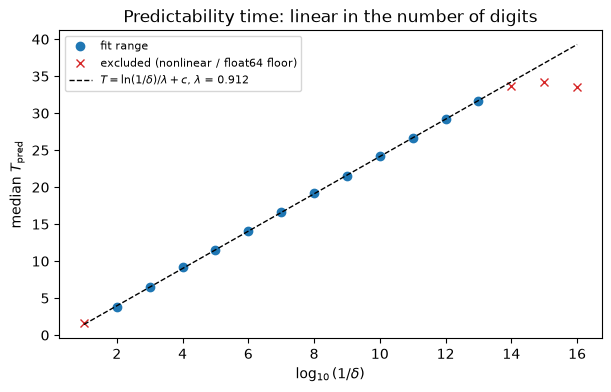

delta = 1e-01: T_pred =   1.66
delta = 1e-02: T_pred =   3.78
delta = 1e-03: T_pred =   6.48
delta = 1e-04: T_pred =   9.16
delta = 1e-05: T_pred =  11.53
delta = 1e-06: T_pred =  14.01
delta = 1e-07: T_pred =  16.67
delta = 1e-08: T_pred =  19.23
delta = 1e-09: T_pred =  21.48
delta = 1e-10: T_pred =  24.27
delta = 1e-11: T_pred =  26.60
delta = 1e-12: T_pred =  29.22
delta = 1e-13: T_pred =  31.63
delta = 1e-14: T_pred =  33.70
delta = 1e-15: T_pred =  34.22   (30% of pairs: delta rounded to 0)
delta = 1e-16: T_pred =  33.52   (86% of pairs: delta rounded to 0)

extra time per decade = 2.523  (ln10/lambda_lit = 2.543); implied lambda = 0.9125; rms residual = 0.10
CHECK 5 (T_pred linear in ln(1/delta) over 12 decades, implied lambda within 5% of 0.906): PASS


In [6]:
DELTA_MAX = 1.0
deltas = 10.0 ** -np.arange(1, 17)
T_pred, frac_lost = [], []
for delta in deltas:
    t, d = separation(s0, delta, DT, round(45 / DT))
    crossed = d.max(axis=0) > DELTA_MAX                       # pairs that ever leave the ball
    T_pred.append(np.median(t[np.argmax(d[:, crossed] > DELTA_MAX, axis=0)]) if crossed.any() else np.nan)
    frac_lost.append(np.mean(d[0] == 0))                     # displacement rounded away entirely
T_pred, frac_lost = np.array(T_pred), np.array(frac_lost)

fit = (deltas <= 1e-2) & (deltas >= 1e-13)
slope, icpt = np.polyfit(np.log(1 / deltas[fit]), T_pred[fit], 1)
resid = T_pred[fit] - np.polyval([slope, icpt], np.log(1 / deltas[fit]))

plt.figure(figsize=(7, 4))
plt.plot(np.log10(1 / deltas[fit]), T_pred[fit], "o", label="fit range")
plt.plot(np.log10(1 / deltas[~fit]), T_pred[~fit], "x", color="C3", label="excluded (nonlinear / float64 floor)")
xx = np.log10(1 / deltas)
plt.plot(xx, np.polyval([slope, icpt], np.log(10) * xx), "k--", lw=1,
         label=rf"$T = \ln(1/\delta)/\lambda + c$, $\lambda$ = {1 / slope:.3f}")
plt.xlabel(r"$\log_{10}(1/\delta)$"); plt.ylabel(r"median $T_{\rm pred}$"); plt.legend(fontsize=8)
plt.title("Predictability time: linear in the number of digits")
plt.show()

for delta, T, lost in zip(deltas, T_pred, frac_lost):
    print(f"delta = {delta:.0e}: T_pred = {T:6.2f}" + (f"   ({100 * lost:.0f}% of pairs: delta rounded to 0)" if lost else ""))
print(f"\nextra time per decade = {slope * np.log(10):.3f}  (ln10/lambda_lit = {np.log(10) / LAMBDA_LIT:.3f}); "
      f"implied lambda = {1 / slope:.4f}; rms residual = {resid.std():.2f}")
print("CHECK 5 (T_pred linear in ln(1/delta) over 12 decades, implied lambda within 5% of 0.906):",
      "PASS" if abs(1 / slope / LAMBDA_LIT - 1) < 0.05 and resid.std() < 0.3 else "FAIL")

## 6. The full Lyapunov spectrum, and an exact check

Benettin/QR method (`chaos.lyapunov_spectrum`). Three tangent vectors are advanced with the
trajectory by $\dot v = J(s)\,v$ and are re-orthonormalised by QR every 10 steps. The logs of
the diagonal of $R$ accumulate into $\lambda_1, \lambda_2, \lambda_3$.

Expectations:
- $\lambda_1 \approx 0.906$, independent of the two-trajectory fit in section 3.
- $\lambda_2 = 0$ exactly in theory: a perturbation along the flow neither grows nor decays.
- $\lambda_1+\lambda_2+\lambda_3 = \operatorname{tr} J = -(\sigma+1+\beta) = -13.6\overline{6}$.
  The trace is the same at every point of phase space, so the sum does not depend on the
  trajectory or on how long it runs.

The sum rule is exact for the flow, but not for RK4. The RK4 tangent propagator does not
conserve phase-space volume exactly, so the sum misses by an $O(dt^4)$ amount. The check
therefore has two parts: the miss is small, and it shrinks by about 16 when $dt$ is halved.

In [7]:
TRACE = -(10 + 1 + 8 / 3)
lam = lyapunov_spectrum(on_attractor(1, seed=0)[0], DT, round(500 / DT))
print(f"lambda = ({lam[0]:.4f}, {lam[1]:.4f}, {lam[2]:.4f}),  sum = {lam.sum():.6f}  vs exact {TRACE:.6f}")

s_short = on_attractor(1, seed=0)[0]
miss = [lyapunov_spectrum(s_short, h, round(50 / h)).sum() - TRACE for h in (DT, DT / 2)]
print(f"sum - exact: dt = {DT}: {miss[0]:.2e},  dt = {DT / 2}: {miss[1]:.2e},  ratio = {miss[0] / miss[1]:.1f}  (RK4: 16)")
print(f"lambda_1 here = {lam[0]:.4f}; two-trajectory fit (section 3, delta=1e-9) = {lams[1e-9]:.4f}")

ok = (abs(lam[0] / LAMBDA_LIT - 1) < 0.05 and abs(lam[1]) < 0.02
      and abs(lam.sum() - TRACE) < 1e-3 and 12 < miss[0] / miss[1] < 20)
print("CHECK 6 (lambda_1 ~ 0.906, |lambda_2| < 0.02, sum = -13.667 with an O(dt^4) miss):", "PASS" if ok else "FAIL")

lambda = (0.9010, 0.0031, -14.5706),  sum = -13.666564  vs exact -13.666667
sum - exact: dt = 0.01: 1.01e-04,  dt = 0.005: 6.20e-06,  ratio = 16.3  (RK4: 16)
lambda_1 here = 0.9010; two-trajectory fit (section 3, delta=1e-9) = 0.9017
CHECK 6 (lambda_1 ~ 0.906, |lambda_2| < 0.02, sum = -13.667 with an O(dt^4) miss): PASS
